This notebook includes runs related to unmixing by using:

1. A very simple MLP, of various different sizes. These sizes are:
    - [32,32]
    - [64^3]
    - [128^4]
    - [256^4]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.mlp import MLP
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [7]:
# Define model configs

models_list = [
    {'hidden_dim': [32, 32]},
    {'hidden_dim': [64, 64, 64]},
    {'hidden_dim': [128, 128, 128, 128]},
    {'hidden_dim': [256, 256, 256, 256]},
    {'hidden_dim': [512, 512, 512, 512, 512]},
    {'hidden_dim': [64, 1024, 1024, 1024, 1024, 64]},
    {'hidden_dim': [64, 2048, 2048, 4096, 2048, 2048, 64]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'mlp_32',
    'mlp_64_3layer',
    'mlp_128_4layer',
    'mlp_256_4layer',
    'mlp_512_5layer',
    'mlp_64_1k_5layer',
    'mlp_64_2k_7layer'
]

name_list = [
        'MLP_32',
        'MLP_64_3layer',
        'MLP_128_4layer',
        'MLP_256_4layer',
        'MLP_512_5layer',
        'MLP_64_1k_5layer',
        'MLP_64_2k_7layer'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'mlp' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.316652
Epoch 1/80, Step 2/47, Train Loss: 0.297328
Epoch 1/80, Step 3/47, Train Loss: 0.315515
Epoch 1/80, Step 4/47, Train Loss: 0.270737
Epoch 1/80, Step 5/47, Train Loss: 0.260822
Epoch 1/80, Step 6/47, Train Loss: 0.273928
Epoch 1/80, Step 7/47, Train Loss: 0.296457
Epoch 1/80, Step 8/47, Train Loss: 0.294088
Epoch 1/80, Step 9/47, Train Loss: 0.240674
Epoch 1/80, Step 10/47, Train Loss: 0.273667
Epoch 1/80, Step 11/47, Train Loss: 0.183882
Epoch 1/80, Step 12/47, Train Loss: 0.265424
Epoch 1/80, Step 13/47, Train Loss: 0.247594
Epoch 1/80, Step 14/47, Train Loss: 0.239729
Epoch 1/80, Step 15/47, Train Loss: 0.202719
Epoch 1/80, Step 16/47, Train Loss: 0.193335
Epoch 1/80, Step 17/47, Train Loss: 0.231721
Epoch 1/80, Step 18/47, Train Loss: 0.141284
Epoch 1/80, Step 19/47, Train Loss: 0.226973
Epoch 1/80, Step 20/47, Train Loss: 0.220611
Epoch 1/80, Step 21/47, Train Loss: 0.202542
Epoch 1/80, Step 22/47, Train Loss: 0.258779
Epoch 1/80, Step 23

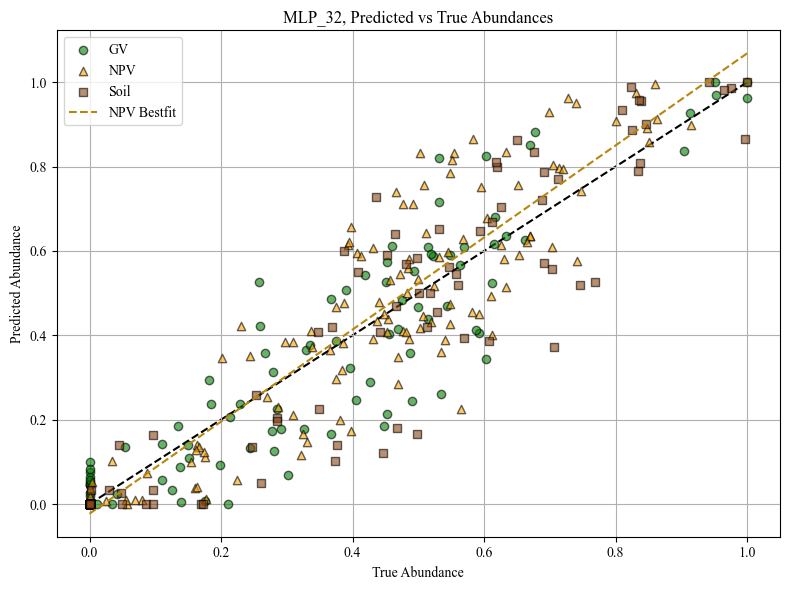

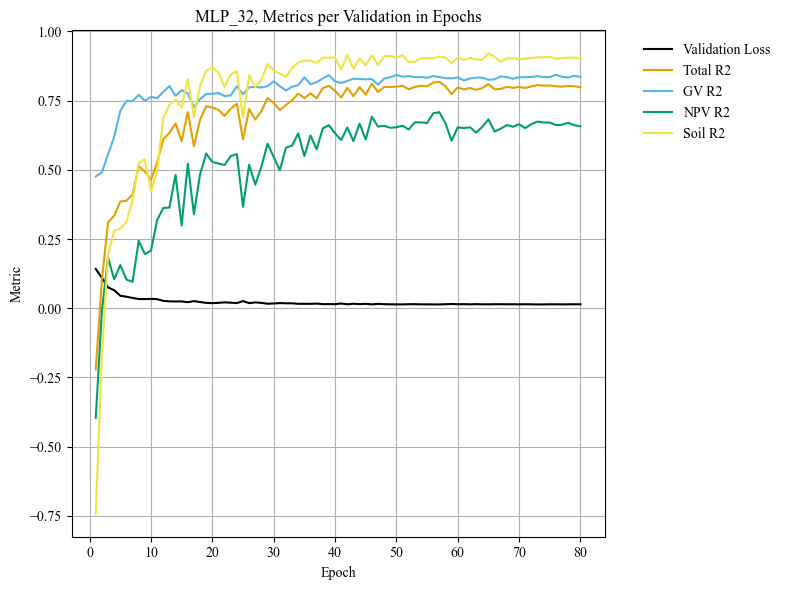

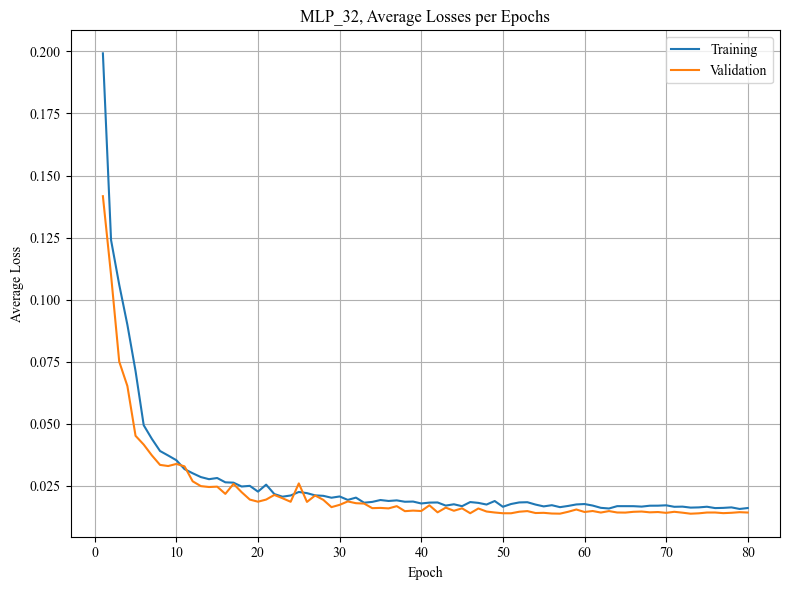

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.247454
Epoch 1/80, Step 2/47, Train Loss: 0.184115
Epoch 1/80, Step 3/47, Train Loss: 0.192236
Epoch 1/80, Step 4/47, Train Loss: 0.163049
Epoch 1/80, Step 5/47, Train Loss: 0.136651
Epoch 1/80, Step 6/47, Train Loss: 0.157497
Epoch 1/80, Step 7/47, Train Loss: 0.176447
Epoch 1/80, Step 8/47, Train Loss: 0.114881
Epoch 1/80, Step 9/47, Train Loss: 0.134870
Epoch 1/80, Step 10/47, Train Loss: 0.087095
Epoch 1/80, Step 11/47, Train Loss: 0.087903
Epoch 1/80, Step 12/47, Train Loss: 0.093515
Epoch 1/80, Step 13/47, Train Loss: 0.069109
Epoch 1/80, Step 14/47, Train Loss: 0.109249
Epoch 1/80, Step 15/47, Train Loss: 0.099195
Epoch 1/80, Step 16/47, Train Loss: 0.033068
Epoch 1/80, Step 17/47, Train Loss: 0.095479
Epoch 1/80, Step 18/47, Train Loss: 0.094502
Epoch 1/80, Step 19/47, Train Loss: 0.077909
Epoch 1/80, Step 20/47, Train Loss: 0.097918
Epoch 1/80, Step 21/47, Train Loss: 0.088343
Epoch 1/80, Step 22/47, Train Loss: 0.094478
Ep

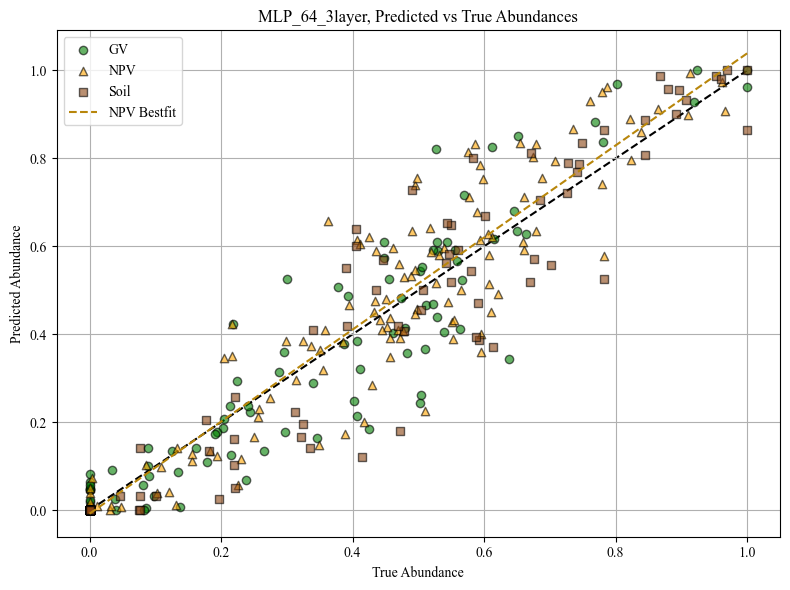

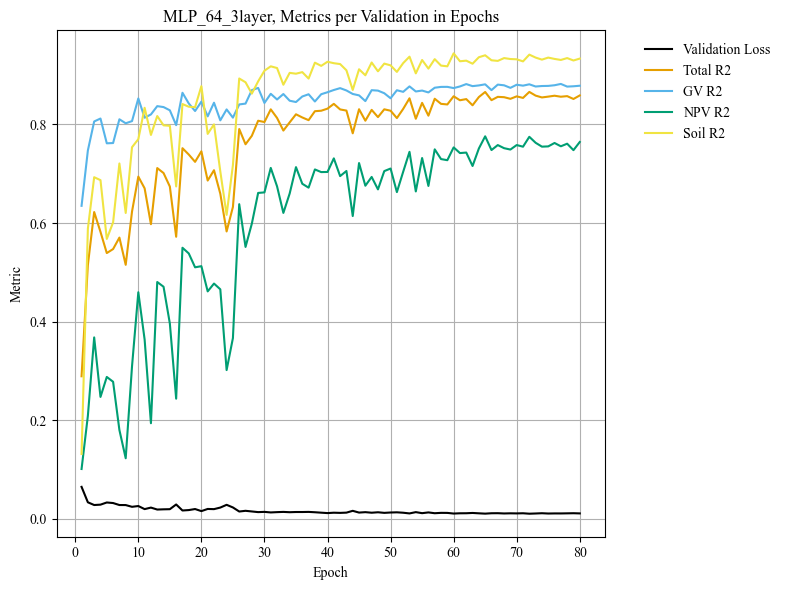

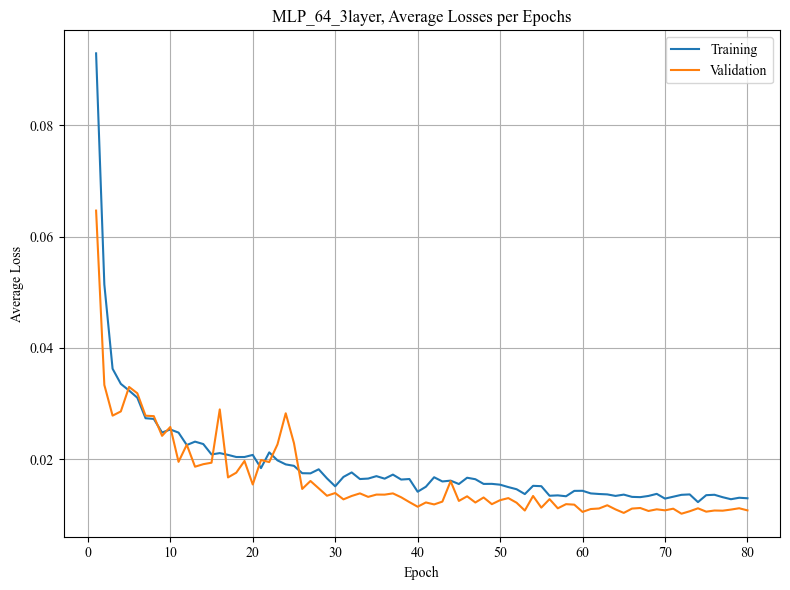

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.231056
Epoch 1/80, Step 2/47, Train Loss: 0.130401
Epoch 1/80, Step 3/47, Train Loss: 0.135219
Epoch 1/80, Step 4/47, Train Loss: 0.130666
Epoch 1/80, Step 5/47, Train Loss: 0.135237
Epoch 1/80, Step 6/47, Train Loss: 0.136375
Epoch 1/80, Step 7/47, Train Loss: 0.086498
Epoch 1/80, Step 8/47, Train Loss: 0.112002
Epoch 1/80, Step 9/47, Train Loss: 0.107789
Epoch 1/80, Step 10/47, Train Loss: 0.088056
Epoch 1/80, Step 11/47, Train Loss: 0.100182
Epoch 1/80, Step 12/47, Train Loss: 0.068733
Epoch 1/80, Step 13/47, Train Loss: 0.070729
Epoch 1/80, Step 14/47, Train Loss: 0.079423
Epoch 1/80, Step 15/47, Train Loss: 0.081876
Epoch 1/80, Step 16/47, Train Loss: 0.039522
Epoch 1/80, Step 17/47, Train Loss: 0.053213
Epoch 1/80, Step 18/47, Train Loss: 0.059935
Epoch 1/80, Step 19/47, Train Loss: 0.052001
Epoch 1/80, Step 20/47, Train Loss: 0.060845
Epoch 1/80, Step 21/47, Train Loss: 0.058045
Epoch 1/80, Step 22/47, Train Loss: 0.066859
Ep

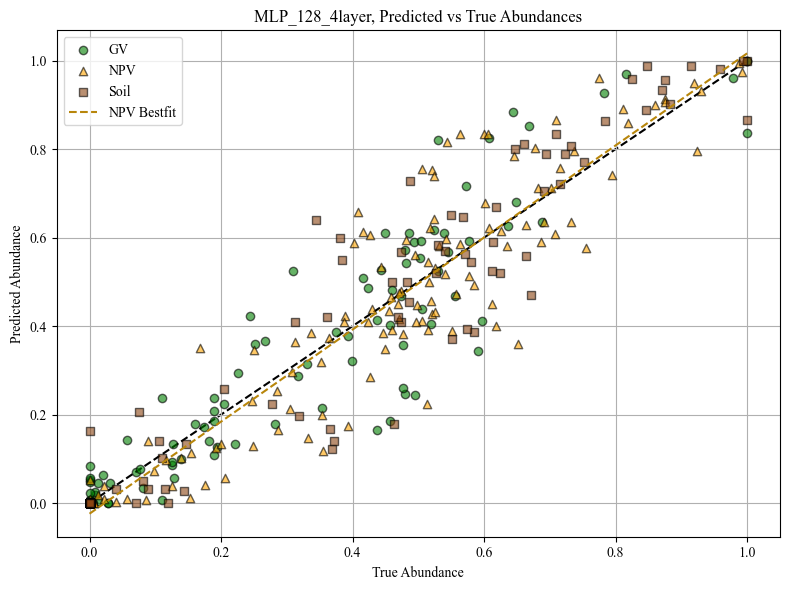

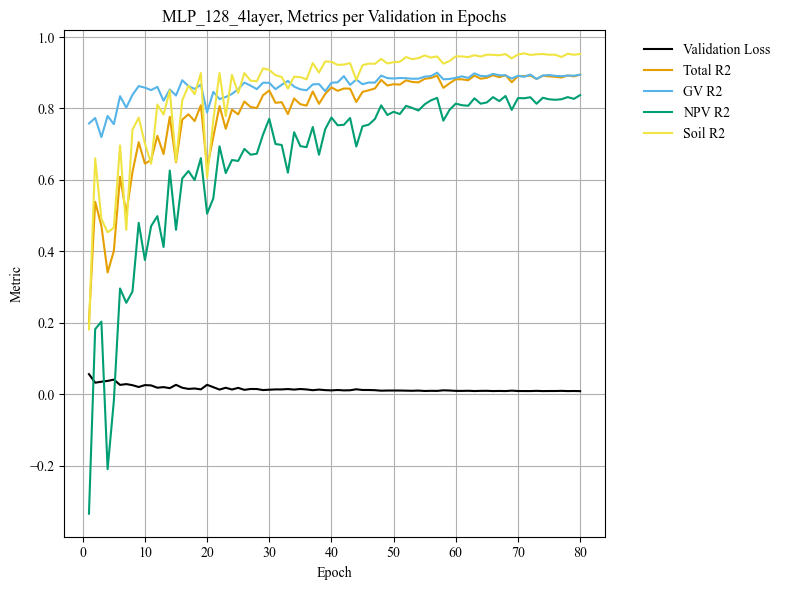

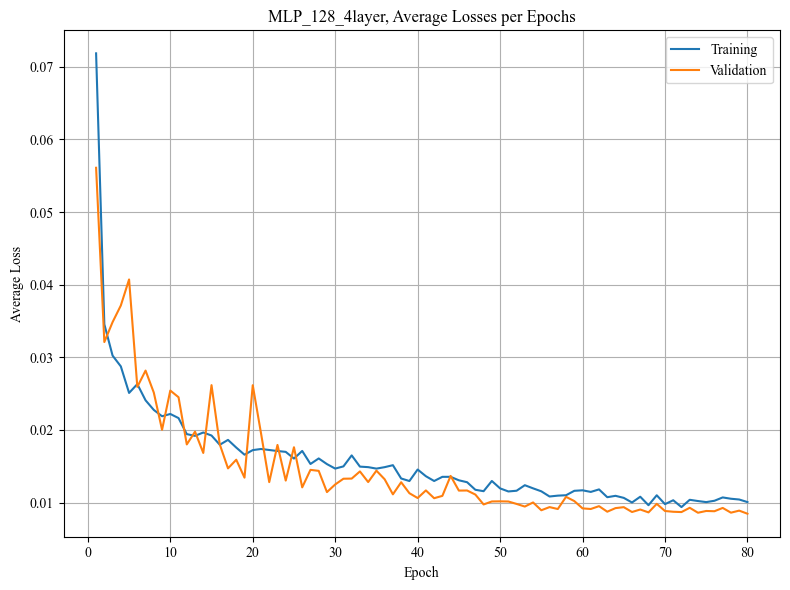

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.144473
Epoch 1/80, Step 2/47, Train Loss: 0.126688
Epoch 1/80, Step 3/47, Train Loss: 0.086645
Epoch 1/80, Step 4/47, Train Loss: 0.097905
Epoch 1/80, Step 5/47, Train Loss: 0.094163
Epoch 1/80, Step 6/47, Train Loss: 0.064405
Epoch 1/80, Step 7/47, Train Loss: 0.108830
Epoch 1/80, Step 8/47, Train Loss: 0.073604
Epoch 1/80, Step 9/47, Train Loss: 0.095502
Epoch 1/80, Step 10/47, Train Loss: 0.055000
Epoch 1/80, Step 11/47, Train Loss: 0.062927
Epoch 1/80, Step 12/47, Train Loss: 0.091757
Epoch 1/80, Step 13/47, Train Loss: 0.086825
Epoch 1/80, Step 14/47, Train Loss: 0.078313
Epoch 1/80, Step 15/47, Train Loss: 0.046189
Epoch 1/80, Step 16/47, Train Loss: 0.055551
Epoch 1/80, Step 17/47, Train Loss: 0.083132
Epoch 1/80, Step 18/47, Train Loss: 0.078531
Epoch 1/80, Step 19/47, Train Loss: 0.097714
Epoch 1/80, Step 20/47, Train Loss: 0.067306
Epoch 1/80, Step 21/47, Train Loss: 0.058220
Epoch 1/80, Step 22/47, Train Loss: 0.029840
Ep

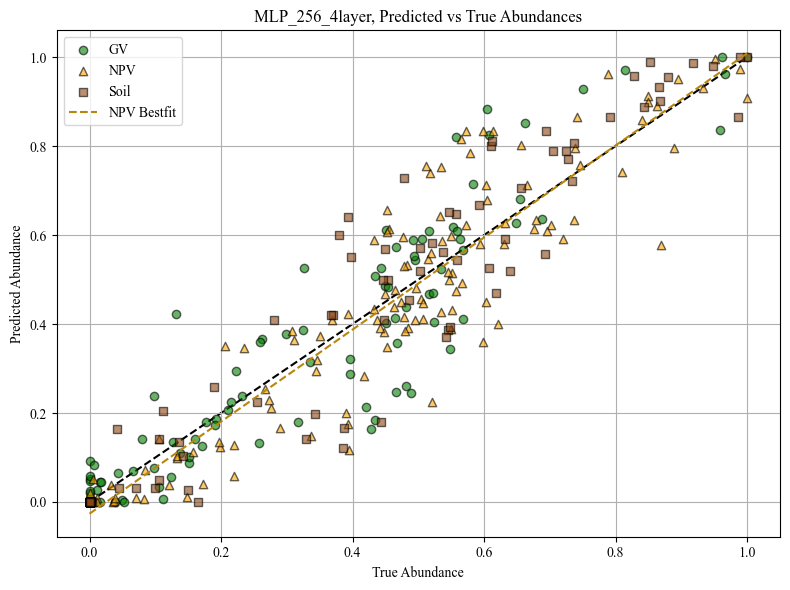

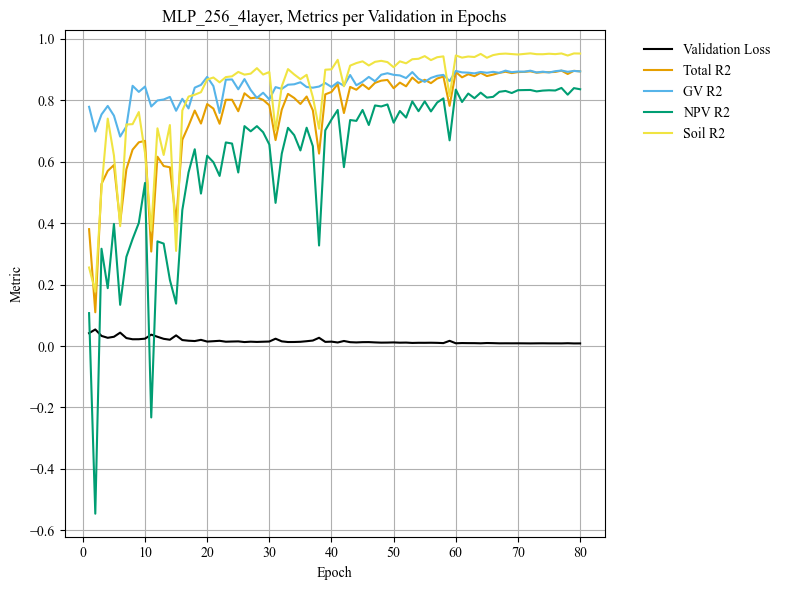

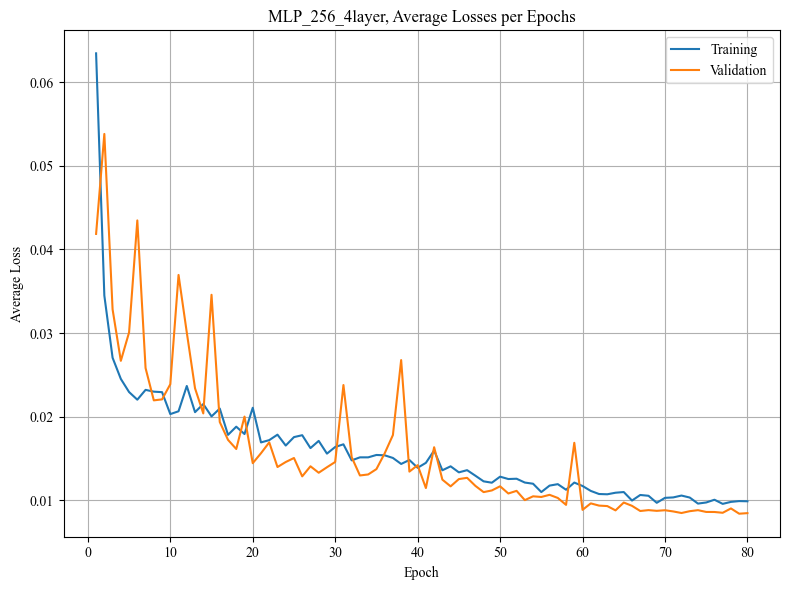

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.325141
Epoch 1/80, Step 2/47, Train Loss: 0.174192
Epoch 1/80, Step 3/47, Train Loss: 0.129925
Epoch 1/80, Step 4/47, Train Loss: 0.073704
Epoch 1/80, Step 5/47, Train Loss: 0.065601
Epoch 1/80, Step 6/47, Train Loss: 0.132215
Epoch 1/80, Step 7/47, Train Loss: 0.114058
Epoch 1/80, Step 8/47, Train Loss: 0.110808
Epoch 1/80, Step 9/47, Train Loss: 0.095967
Epoch 1/80, Step 10/47, Train Loss: 0.080626
Epoch 1/80, Step 11/47, Train Loss: 0.091725
Epoch 1/80, Step 12/47, Train Loss: 0.065372
Epoch 1/80, Step 13/47, Train Loss: 0.104271
Epoch 1/80, Step 14/47, Train Loss: 0.106206
Epoch 1/80, Step 15/47, Train Loss: 0.081708
Epoch 1/80, Step 16/47, Train Loss: 0.083718
Epoch 1/80, Step 17/47, Train Loss: 0.074106
Epoch 1/80, Step 18/47, Train Loss: 0.065803
Epoch 1/80, Step 19/47, Train Loss: 0.095432
Epoch 1/80, Step 20/47, Train Loss: 0.076206
Epoch 1/80, Step 21/47, Train Loss: 0.059633
Epoch 1/80, Step 22/47, Train Loss: 0.078131
Ep

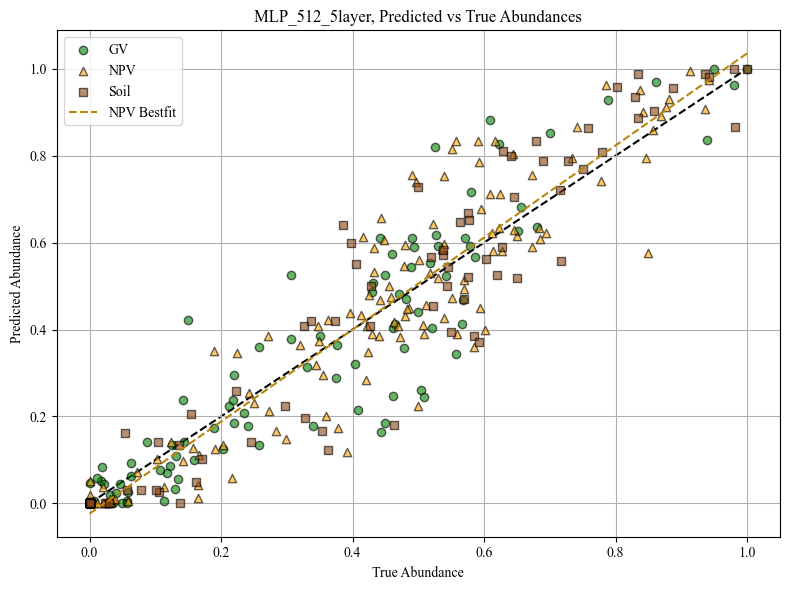

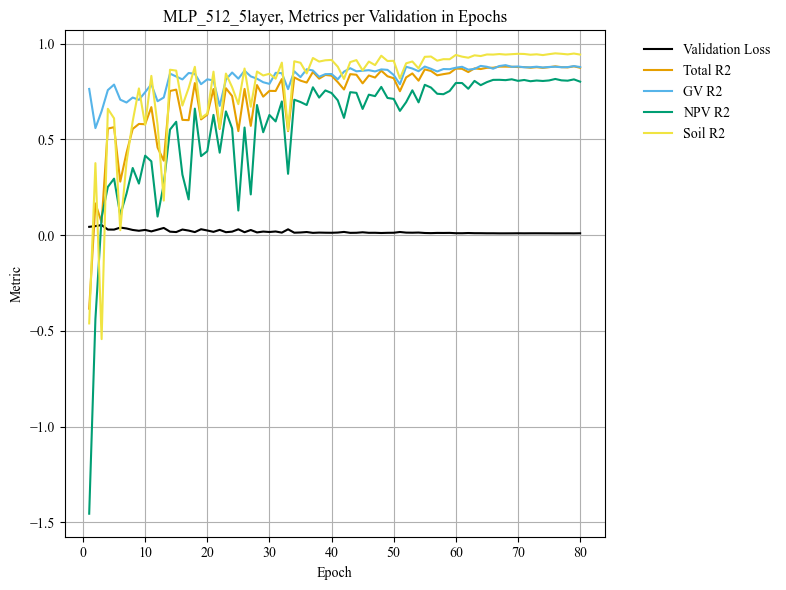

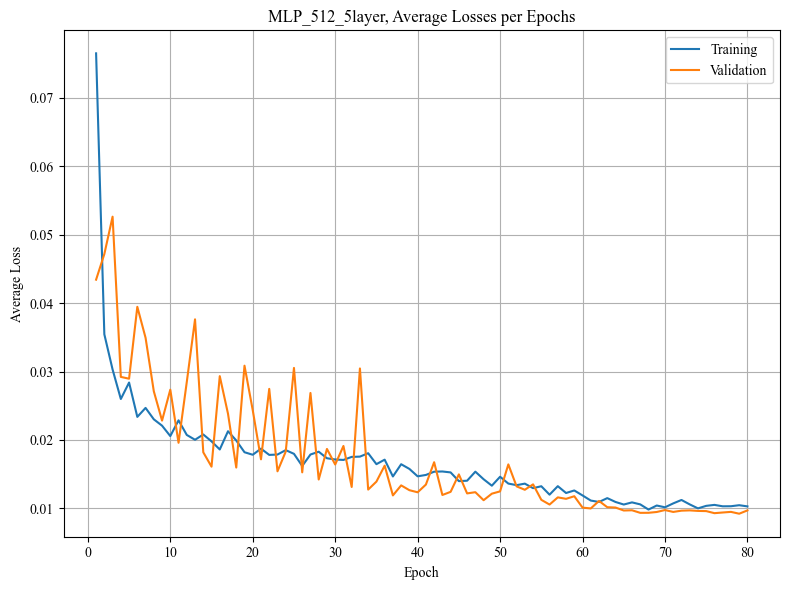

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.195158
Epoch 1/80, Step 2/47, Train Loss: 0.249794
Epoch 1/80, Step 3/47, Train Loss: 0.249237
Epoch 1/80, Step 4/47, Train Loss: 0.190580
Epoch 1/80, Step 5/47, Train Loss: 0.165610
Epoch 1/80, Step 6/47, Train Loss: 0.198165
Epoch 1/80, Step 7/47, Train Loss: 0.156689
Epoch 1/80, Step 8/47, Train Loss: 0.174070
Epoch 1/80, Step 9/47, Train Loss: 0.176678
Epoch 1/80, Step 10/47, Train Loss: 0.242077
Epoch 1/80, Step 11/47, Train Loss: 0.158623
Epoch 1/80, Step 12/47, Train Loss: 0.166969
Epoch 1/80, Step 13/47, Train Loss: 0.174062
Epoch 1/80, Step 14/47, Train Loss: 0.171189
Epoch 1/80, Step 15/47, Train Loss: 0.209691
Epoch 1/80, Step 16/47, Train Loss: 0.179520
Epoch 1/80, Step 17/47, Train Loss: 0.173630
Epoch 1/80, Step 18/47, Train Loss: 0.144785
Epoch 1/80, Step 19/47, Train Loss: 0.171852
Epoch 1/80, Step 20/47, Train Loss: 0.108108
Epoch 1/80, Step 21/47, Train Loss: 0.144133
Epoch 1/80, Step 22/47, Train Loss: 0.190464
Ep

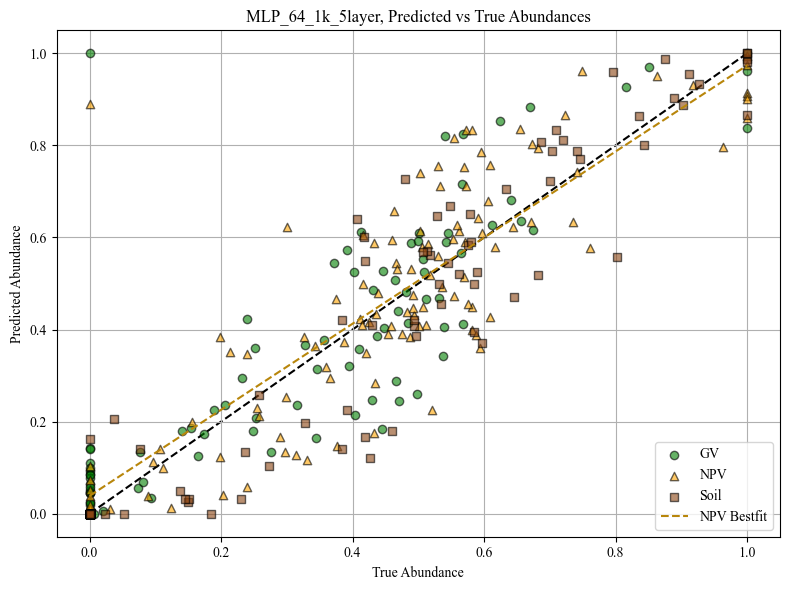

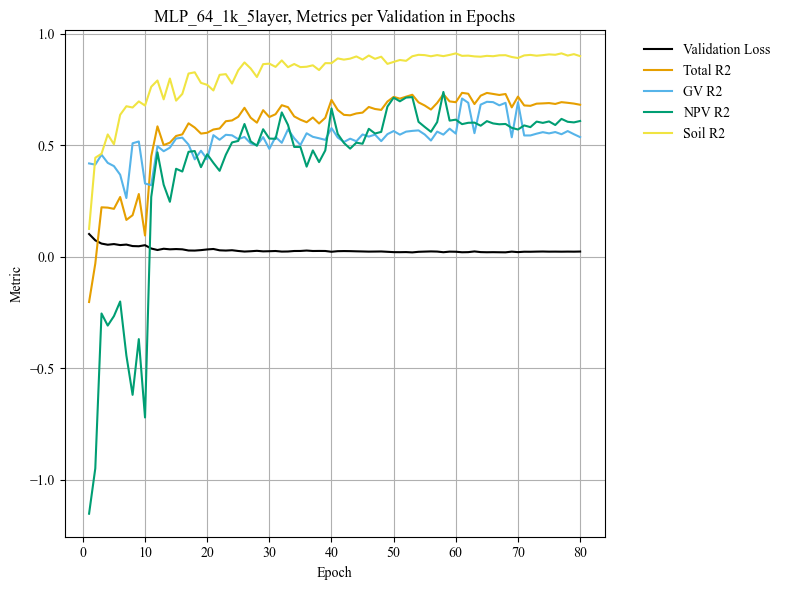

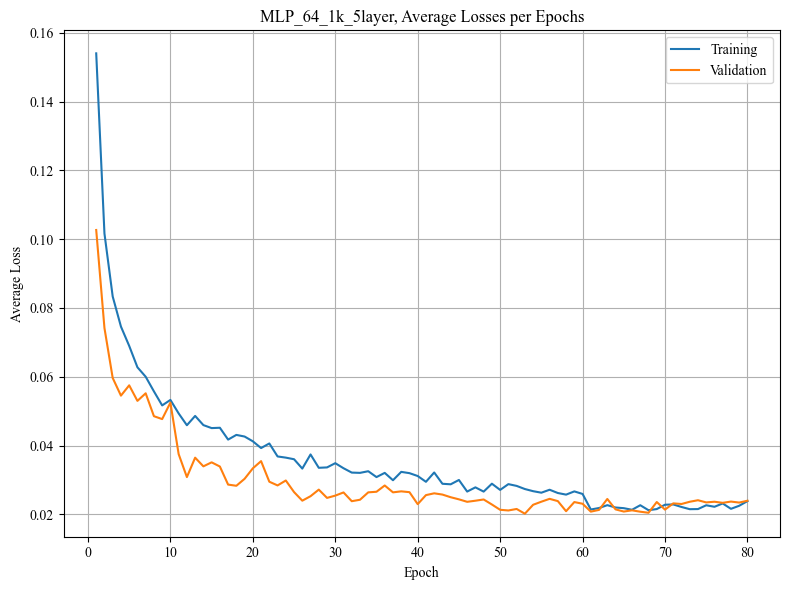

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.212467
Epoch 1/80, Step 2/47, Train Loss: 0.132565
Epoch 1/80, Step 3/47, Train Loss: 0.154233
Epoch 1/80, Step 4/47, Train Loss: 0.121633
Epoch 1/80, Step 5/47, Train Loss: 0.091660
Epoch 1/80, Step 6/47, Train Loss: 0.109170
Epoch 1/80, Step 7/47, Train Loss: 0.089988
Epoch 1/80, Step 8/47, Train Loss: 0.108212
Epoch 1/80, Step 9/47, Train Loss: 0.107706
Epoch 1/80, Step 10/47, Train Loss: 0.060956
Epoch 1/80, Step 11/47, Train Loss: 0.107184
Epoch 1/80, Step 12/47, Train Loss: 0.094883
Epoch 1/80, Step 13/47, Train Loss: 0.095544
Epoch 1/80, Step 14/47, Train Loss: 0.111463
Epoch 1/80, Step 15/47, Train Loss: 0.106873
Epoch 1/80, Step 16/47, Train Loss: 0.107495
Epoch 1/80, Step 17/47, Train Loss: 0.057537
Epoch 1/80, Step 18/47, Train Loss: 0.074339
Epoch 1/80, Step 19/47, Train Loss: 0.069930
Epoch 1/80, Step 20/47, Train Loss: 0.084533
Epoch 1/80, Step 21/47, Train Loss: 0.092574
Epoch 1/80, Step 22/47, Train Loss: 0.090931
Ep

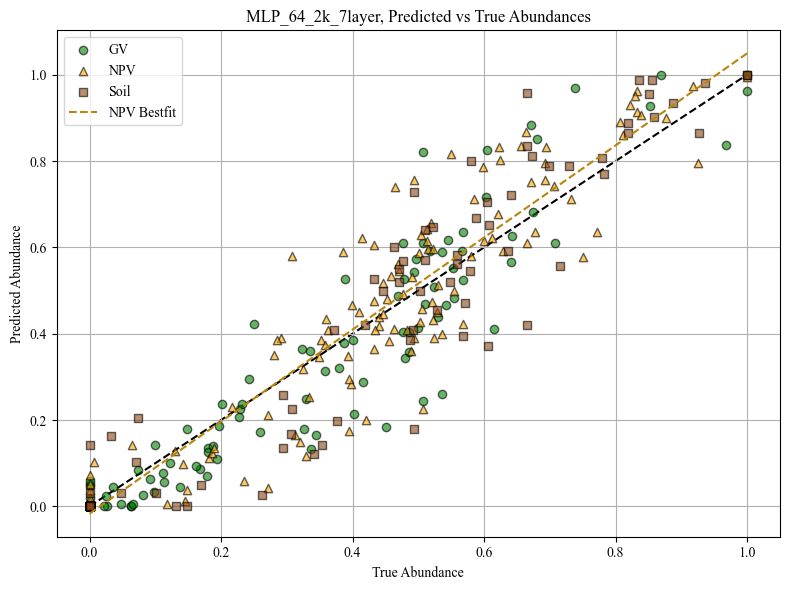

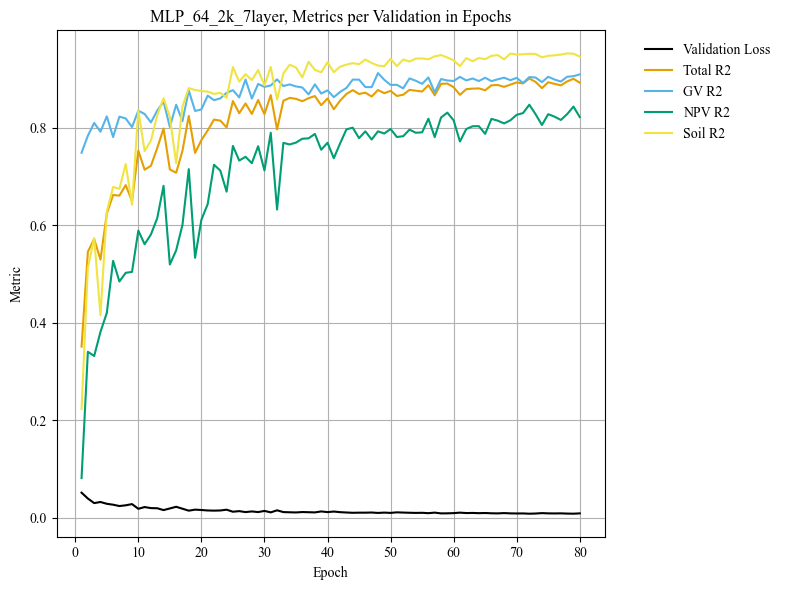

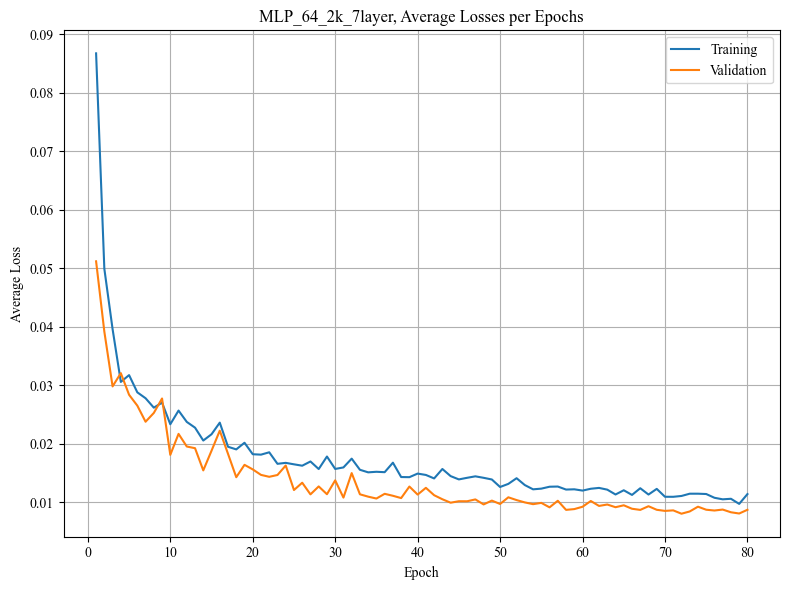

Testing complete


In [8]:
mlp_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1700], batch_size=32)
    model = MLP(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    mlp_dict[model_name] = model_dict

In [10]:
import pickle
with open('mlp_dict.pkl', 'wb') as fp:
    pickle.dump(mlp_dict, fp)